In [1]:
# Cell 1: Import necessary libraries and load the data
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import KFold

# Set a random seed for reproducibility
np.random.seed(42)

# Load the data from the .mat file
try:
    mat_content = loadmat('data/data.mat')
    
    # Assume the 201x2 array is stored under a key.
    # Iterate through keys to find the array with the expected dimensions.
    data_array = None
    for key in mat_content:
        if isinstance(mat_content[key], np.ndarray) and mat_content[key].shape == (201, 2):
            data_array = mat_content[key]
            break
            
    if data_array is not None:
        # First column is X values, second column is y values
        X_full = data_array[:, 0].flatten() 
        y_full = data_array[:, 1].flatten() 
        print("Data loaded successfully from 'data.mat'.")
        print(f"Shape of X: {X_full.shape}")
        print(f"Shape of y: {y_full.shape}")
    else:
        print("Error: Could not find a 201x2 array in data.mat. Please check the file content.")
        # If the file actually uses 'x' and 'y' keys, you can uncomment these lines instead:
        # X_full = mat_content['x'].flatten()
        # y_full = mat_content['y'].flatten()
        raise KeyError("Relevant data array (201x2) not found in 'data.mat'.")

except FileNotFoundError:
    print("Error: data.mat not found. Please ensure the file is in the same directory as your notebook.")
    raise FileNotFoundError("data.mat is required for this problem.")

# Define the locally weighted linear regression prediction function
def local_linear_regression_predict(x_pred, X_train, y_train, h):
    """
    Performs local linear regression to predict y_pred at a single point x_pred.
    
    Args:
        x_pred (float): The point at which to make a prediction.
        X_train (np.ndarray): Training feature data.
        y_train (np.ndarray): Training target data.
        h (float): The bandwidth parameter.
        
    Returns:
        float: The predicted y value.
    """
    n = len(X_train)
    p = 1  # For this problem, p=1 as x is 1-dimensional
    
    # Calculate weights based on the Gaussian kernel
    # K_h(z) = exp(-||z||^2 / (2*h^2)) -- omitting constant scaling factor
    diff_sq = (x_pred - X_train)**2
    weights = np.exp(-diff_sq / (2 * h**2))
    
    W = np.diag(weights)
    
    # Construct the design matrix X as defined in the derivation:
    # X = [1, (x - x_i)]
    X = np.vstack([np.ones(n), (x_pred - X_train)]).T
    
    # Calculate beta_hat = (X^T W X)^{-1} X^T W y
    try:
        # Using @ for matrix multiplication (Python 3.5+)
        beta_hat = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y_train
    except np.linalg.LinAlgError:
        # Handle cases where (X.T @ W @ X) might be singular, often due to
        # very small 'h' values leading to near-zero weights for many points.
        return np.nan # Return NaN, which np.nanmean will ignore in CV
    
    # The predicted y value at point 'x_pred' is the intercept term (beta_0)
    # as the local linear model is centered at 'x_pred'.
    y_pred = beta_hat[0]
    
    return y_pred

Data loaded successfully from 'data.mat'.
Shape of X: (201,)
Shape of y: (201,)


Performing 5-fold cross-validation...
  h = 0.0316, Average MSE = 0.0210
  h = 0.0401, Average MSE = 0.0181
  h = 0.0509, Average MSE = 0.0161
  h = 0.0646, Average MSE = 0.0149
  h = 0.0820, Average MSE = 0.0142
  h = 0.1040, Average MSE = 0.0137
  h = 0.1320, Average MSE = 0.0134
  h = 0.1675, Average MSE = 0.0131
  h = 0.2126, Average MSE = 0.0129
  h = 0.2698, Average MSE = 0.0130
  h = 0.3424, Average MSE = 0.0138
  h = 0.4344, Average MSE = 0.0163
  h = 0.5513, Average MSE = 0.0222
  h = 0.6996, Average MSE = 0.0347
  h = 0.8877, Average MSE = 0.0590
  h = 1.1265, Average MSE = 0.1019
  h = 1.4295, Average MSE = 0.1683
  h = 1.8139, Average MSE = 0.2530
  h = 2.3018, Average MSE = 0.3466
  h = 2.9209, Average MSE = 0.4511
  h = 3.7065, Average MSE = 0.5585
  h = 4.7034, Average MSE = 0.6512
  h = 5.9685, Average MSE = 0.7212
  h = 7.5737, Average MSE = 0.7700
  h = 9.6108, Average MSE = 0.8026
  h = 12.1957, Average MSE = 0.8236
  h = 15.4759, Average MSE = 0.8370
  h = 19.6383, 

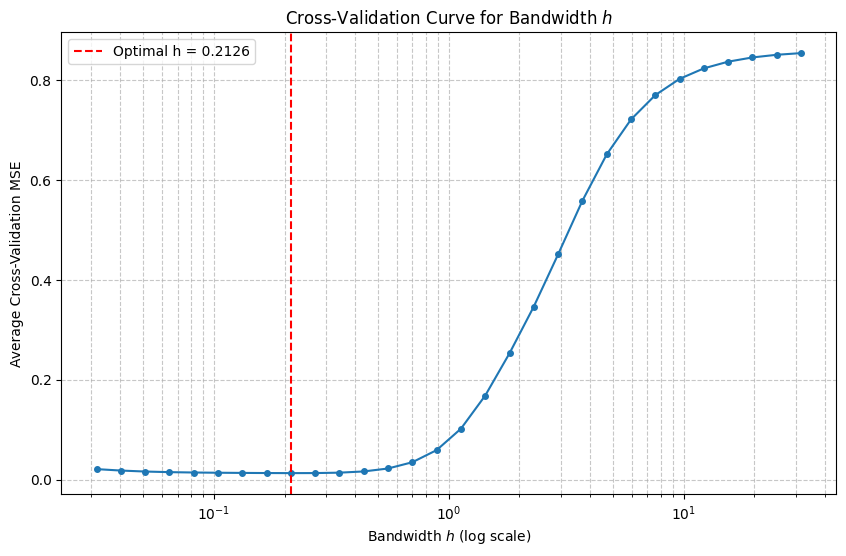

In [2]:
# Cell 2: 5-fold cross-validation to tune the bandwidth parameter h

# Define the range of bandwidth values (h) to test
# Using a logarithmic scale to explore a wide range effectively
h_values = np.logspace(-1.5, 1.5, 30) # From approx 0.03 to 31.6

# Set up 5-fold cross-validation
# shuffle=True to ensure random splits, random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List to store the average mean squared error (MSE) for each h
cv_mse = []

print("Performing 5-fold cross-validation...")
# Iterate over each bandwidth value
for i, h in enumerate(h_values):
    fold_mses = []
    # Iterate over each fold
    for train_index, val_index in kf.split(X_full):
        # Split data for the current fold
        X_train_fold, X_val_fold = X_full[train_index], X_full[val_index]
        y_train_fold, y_val_fold = y_full[train_index], y_full[val_index]
        
        # Make predictions for all validation points in the current fold
        y_pred_fold = np.array([
            local_linear_regression_predict(x_val, X_train_fold, y_train_fold, h)
            for x_val in X_val_fold
        ])
        
        # Calculate Mean Squared Error (MSE) for the current fold
        # np.nanmean is used to correctly handle any NaN predictions (from singular matrix)
        mse = np.nanmean((y_pred_fold - y_val_fold)**2)
        fold_mses.append(mse)
    
    # Compute the average MSE across all folds for this 'h' value
    avg_mse = np.nanmean(fold_mses) # Use nanmean in case a fold produced all NaNs
    cv_mse.append(avg_mse)
    print(f"  h = {h:.4f}, Average MSE = {avg_mse:.4f}")

print("\nCross-validation complete.")

# Find the optimal bandwidth h (the one that yields the minimum average CV MSE)
# np.nanargmin is used to correctly handle potential NaN values in cv_mse
optimal_h_idx = np.nanargmin(cv_mse)
optimal_h = h_values[optimal_h_idx]
min_mse = cv_mse[optimal_h_idx]

print(f"\nOptimal bandwidth h: {optimal_h:.4f}")
print(f"Minimum average CV MSE: {min_mse:.4f}")

# Plot the cross-validation curve
plt.figure(figsize=(10, 6))
plt.plot(h_values, cv_mse, marker='o', linestyle='-', markersize=4)
plt.axvline(x=optimal_h, color='r', linestyle='--', label=f'Optimal h = {optimal_h:.4f}')
plt.title('Cross-Validation Curve for Bandwidth $h$')
plt.xlabel('Bandwidth $h$ (log scale)')
plt.ylabel('Average Cross-Validation MSE')
plt.xscale('log') # Use log scale for x-axis as h_values are log-spaced
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend()
plt.show()


Predicted y value for x = -1.0: 2.3204


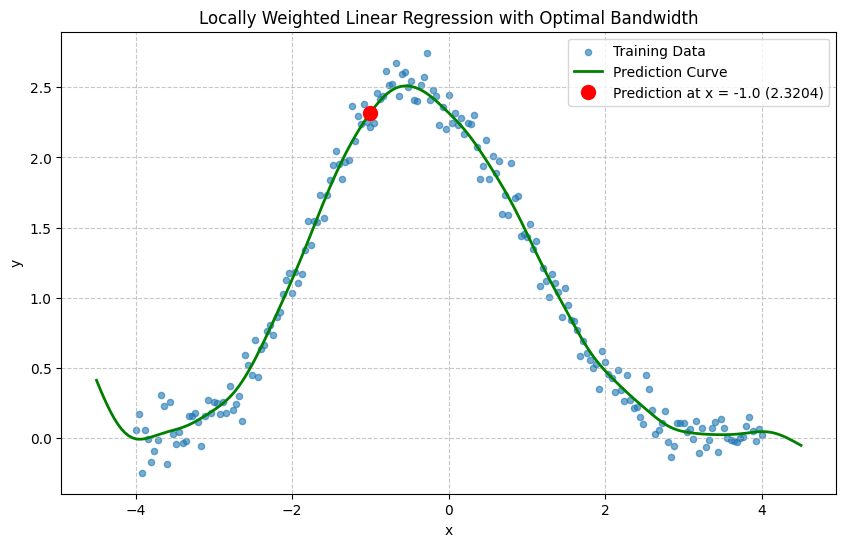

In [3]:
# Cell 3: Make a prediction and visualize the results

# Make a prediction for x = -1 using the optimal h
# Use the entire dataset for training the final model, as instructed.
x_pred_point = -1.0
y_pred_point = local_linear_regression_predict(x_pred_point, X_full, y_full, optimal_h)

print(f"\nPredicted y value for x = {x_pred_point}: {y_pred_point:.4f}")

# Create a smooth prediction curve for a range of x values
# Generate a denser range of x values covering the span of the training data
x_curve = np.linspace(X_full.min() - 0.5, X_full.max() + 0.5, 200) # Extend slightly beyond min/max
y_curve = np.array([
    local_linear_regression_predict(x, X_full, y_full, optimal_h)
    for x in x_curve
])

# Plot the results
plt.figure(figsize=(10, 6))

# Plot the training data as scatter points
plt.scatter(X_full, y_full, label='Training Data', alpha=0.6, s=20)

# Plot the prediction curve as a line
# Filter out any NaN values from y_curve if they occurred during prediction
valid_indices = ~np.isnan(y_curve)
plt.plot(x_curve[valid_indices], y_curve[valid_indices], color='green', linewidth=2, label='Prediction Curve')

# Plot the specific prediction point as a red star marker
plt.plot(x_pred_point, y_pred_point, 'ro', markersize=10, label=f'Prediction at x = {x_pred_point} ({y_pred_point:.4f})')

plt.title('Locally Weighted Linear Regression with Optimal Bandwidth')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()